## Загрузка исходных датасетов

- `load_from_cdaweb` - параметр, отвечающий за источник откуда будет произведена загрузка данных.
- `loader` - экзампляр класса, обеспичвающий загрузку данных.
- `get_*_data()` - соответственные методы по загрузке определённых данных.

| Вызов | Содержимое колонок |
|--------|---------------------|
| `get_ssc_data()` | **Time** — время; **Latitude**, **Longitude** — широта/долгота (GSM); **L** — L-шелл; **GSM_X**, **GSM_Y**, **GSM_Z** — позиция аппарата в GSM (км). |
| `get_fgm_data()` | **Time**; **GSM_Bx**, **GSM_By**, **GSM_Bz** — вектор магнитного поля в GSM (нТ). |
| `get_esa_data(particle="ion")` | **Time**; **GSM_Vix**, **GSM_Viy**, **GSM_Viz** — скорость ионов в GSM (км/с). |
| `get_esa_data(particle="electron")` | **Time**; **GSM_Vex**, **GSM_Vey**, **GSM_Vez** — скорость электронов в GSM (км/с). |
| `get_efi_data()` | **Time**; **GSM_Ex**, **GSM_Ey**, **GSM_Ez** — электрическое поле в GSM (единицы как в CDF, часто мВ/м). |
| `get_sta_data()` | **Time**; **GSM_Vsx**, **GSM_Vsy**, **GSM_Vsz** — скорость спутника в GSM (км/с). |
| `get_omn_data()` | **Time**; **FP** — динамическое давление солнечного ветра; **Bz_GSM** — компонента Bz в GSM. |

Общее: после загрузки отброшены строки без валидного **Time**, дубликаты по **Time** удалены. Интервал и спутник задаются в `config.reading`; OMNI — околоземный ряд, не привязан к букве спутника по смыслу данных.

In [1]:
from backend.src.io.loader import DataDownloading
from backend.src.config import config
from backend.src.processing.utils.h_parameter_range import show_h_parameter_range

In [2]:
load_from_cdaweb = False
loader = DataDownloading(config, load_from_cdaweb=load_from_cdaweb)

In [3]:
ssc_data = loader.get_ssc_data()
fgm_data = loader.get_fgm_data()
esa_ion_data = loader.get_esa_data(particle="ion")
# esa_electron_data = loader.get_esa_data(particle="electron")
efi_data = loader.get_efi_data()
sta_data = loader.get_sta_data()
omn_data = loader.get_omn_data()

## Пересечение промежутков

In [4]:
from datetime import timedelta

from backend.src.processing import AvailabilityIntervals
from backend.src.processing.intersections import intersect_many, summarize_intervals

In [5]:
availability = AvailabilityIntervals(show_progress=True)

ssc_intervals = availability.from_dataframe(ssc_data, "ssc")
fgm_intervals = availability.from_dataframe(fgm_data, "fgm")
esa_ion_intervals = availability.from_dataframe(esa_ion_data, "esa_ion")
# esa_electron_intervals = availability.from_dataframe(esa_electron_data, "esa_electron")
efi_intervals = availability.from_dataframe(efi_data, "efi")
sta_intervals = availability.from_dataframe(sta_data, "sta")
omn_intervals = availability.from_dataframe(omn_data, "omn")

Определение интервалов: 100%|██████████| 320/320 [00:00<00:00, 26473.45it/s]


In [6]:
interval_intersections = intersect_many(
    interval_groups=[
        ssc_intervals,
        sta_intervals,
        efi_intervals,
        fgm_intervals,
        esa_ion_intervals,
    ],
    min_duration=timedelta(hours=1),
)

summarize_intervals(interval_intersections)

{'count': 3,
 'first': (Timestamp('2017-01-01 20:35:13'), Timestamp('2017-01-02 00:21:13')),
 'last': (Timestamp('2017-01-02 19:35:17'), Timestamp('2017-01-03 03:04:57'))}

## Визуализация пересечений

In [7]:
# availability.show(esa_ion_data, esa_ion_intervals, "esa_ion")

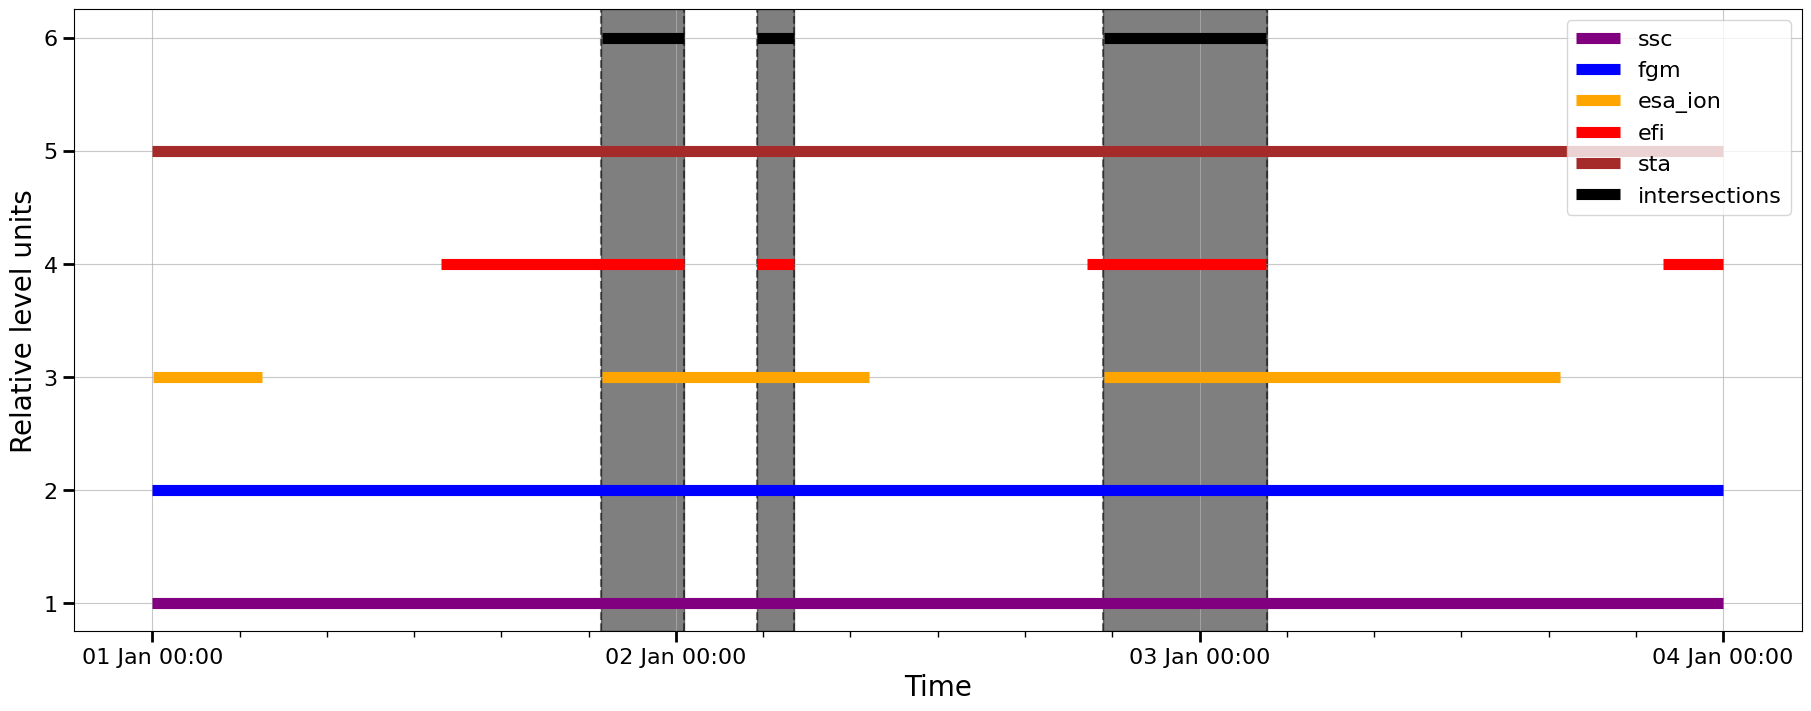

In [8]:
intervals_list = [
    {'intervals': ssc_intervals, "data_type": "ssc"},
    {'intervals': fgm_intervals, "data_type": "fgm"},
    {'intervals': esa_ion_intervals, "data_type": "esa_ion"},
    {'intervals': efi_intervals, "data_type": "efi"},
    {'intervals': sta_intervals, "data_type": "sta"},
    {'intervals': interval_intersections, "data_type": "intersections"},
]

availability.show_intervals(ssc_data, intervals_list)

## Модель Shue 1997 года